# Jessica Bagayogo — Exploratory Data Analysis
## RescueGroups.org Cat Adoption Dataset

---

### Research Question
**Does listing quality and cat behavior influence how long a cat stays in the shelter system before being adopted?**

This notebook explores whether factors like the number of photos in a listing, vaccination status, and whether a cat is kid-friendly are associated with faster or slower adoption times.

### Variables Explored
| Variable | Type | Description |
|---|---|---|
| `length_of_stay` | Quantitative (Dependent) | Days between availability and adoption |
| `pictureCount` | Quantitative | Number of photos in the listing |
| `energyLevel` | Categorical | Cat's energy level (Low, Moderate, High) |
| `isCurrentVaccinations` | Boolean | Whether the cat is up-to-date on vaccines |
| `isDeclawed` | Boolean | Whether the cat has been declawed |
| `isKidsOk` | Boolean | Whether the cat is safe around children |

---

## Section 1 — Setup & Load Data

We begin by importing the libraries we need and loading the cleaned dataset. The dataset contains 4,528 records of cats that have been adopted through the RescueGroups.org system.

In [7]:
%%capture
!pip install seaborn

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('../data/clean/clean_cats_data.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (4528, 27)


,Unnamed: 0,id,sex,sizeCurrent,sizeGroup,ageGroup,ageString,breedString,colorDetails,vocalLevel,...,isKidsOk,adultSexesOk,obedienceTraining,ownerExperience,newPeopleReaction,pictureCount,videoCount,adoptedDate,availableDate,length_of_stay
0,2,10000193,Male,14.0,Large,Adult,8 Years 8 Months,Domestic Short Hair / Mixed,NaN,NaN,...,True,NaN,NaN,NaN,NaN,5,0,2016-08-13 00:00:00+00:00,2016-05-17 00:00:00+00:00,88.0
1,9,10000236,Female,NaN,NaN,Adult,10 Years 6 Months,Domestic Short Hair (short coat),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4,0,2016-06-25 00:00:00+00:00,2016-05-14 00:00:00+00:00,42.0
2,10,10000242,Female,NaN,NaN,Baby,6 Years 8 Months,Domestic Short Hair (short coat),White w/calico,NaN,...,NaN,NaN,NaN,NaN,NaN,2,0,2016-05-28 00:00:00+00:00,2016-05-14 00:00:00+00:00,14.0
3,11,10000252,Female,NaN,NaN,Baby,6 Years 8 Months,Domestic Short Hair (short coat),Tabby w/white,NaN,...,NaN,NaN,NaN,NaN,NaN,2,0,2016-05-28 00:00:00+00:00,2016-05-14 00:00:00+00:00,14.0
4,20,10000959,Male,NaN,Medium,Adult,NaN,Domestic Short Hair (short coat),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,2016-06-11 00:00:00+00:00,2016-05-13 00:00:00+00:00,29.0


## Section 2 — Null Check & Data Overview

Before diving into analysis, it's important to understand how complete our data is. Many columns in this dataset have missing values — this matters because it affects how much we can rely on any patterns we find.

For example, if only 600 out of 4,528 cats have an `energyLevel` listed, any conclusions we draw from that column apply to a small fraction of cats, which may not represent the full population.

In [9]:
# Count missing values per column, sorted from most to least missing
null_counts = df.isnull().sum().sort_values(ascending=False)
print('Missing values per column:')
print(null_counts)

Missing values per column:
ownerExperience          4334
obedienceTraining        4176
vocalLevel               3923
sheddingLevel            3720
exerciseNeeds            3430
colorDetails             3224
energyLevel              3115
adultSexesOk             2905
sizeCurrent              2844
newPeopleReaction        2736
isKidsOk                 2222
sizeGroup                1586
isCurrentVaccinations    1533
isDeclawed               1475
isHousetrained           1245
isSpecialNeeds           1140
ageGroup                  390
ageString                 332
sex                        32
breedString                 0
id                          0
Unnamed: 0                  0
pictureCount                0
videoCount                  0
adoptedDate                 0
availableDate               0
length_of_stay              0
dtype: int64


In [10]:
# Summary statistics for numeric columns
df[['pictureCount', 'length_of_stay']].describe().round(2)

,pictureCount,length_of_stay
count,4528.00,4528.00
mean,2.71,73.51
std,2.31,196.66
min,0.00,0.00
25%,1.00,9.00
50%,2.00,25.00
75%,4.00,63.00
max,23.00,3481.00


**Key Observations:**
- `pictureCount` and `length_of_stay` have no missing values — making them reliable for analysis.
- `energyLevel` is missing for roughly 70% of cats.
- `isCurrentVaccinations`, `isDeclawed`, and `isKidsOk` are each missing for 30–50% of cats.
- We will keep these limitations in mind as we interpret our charts.

---

## Section 3 — Univariate Analysis
### How is each variable distributed on its own?

Before comparing variables to each other, we look at each one individually to understand its range and shape.

### 3a. Picture Count
How many photos do most cat listings include? More photos may signal a more complete and attractive listing — which could influence how quickly a cat is adopted.

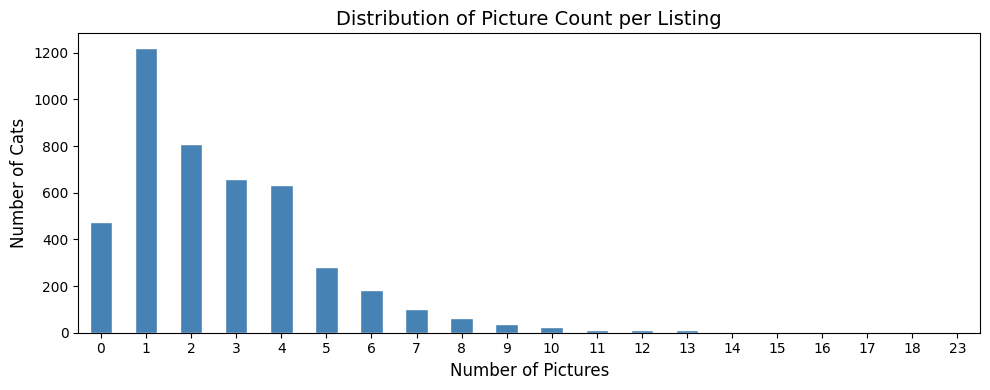

Average pictures per listing: 2.71
Cats with 0 pictures: 474


In [11]:
plt.figure(figsize=(10, 4))
df['pictureCount'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribution of Picture Count per Listing', fontsize=14)
plt.xlabel('Number of Pictures', fontsize=12)
plt.ylabel('Number of Cats', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Average pictures per listing: {df['pictureCount'].mean():.2f}")
print(f"Cats with 0 pictures: {(df['pictureCount'] == 0).sum()}")

### 3b. Energy Level
Energy level describes how active a cat is. Some adopters may prefer calm cats; others may want an energetic companion. Let's see how the available values break down.

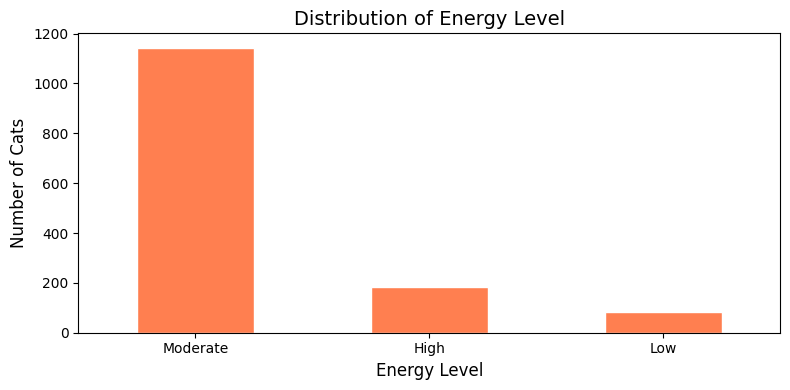

Cats with energy level listed: 1413 out of 4528


In [12]:
plt.figure(figsize=(8, 4))
df['energyLevel'].value_counts().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Distribution of Energy Level', fontsize=14)
plt.xlabel('Energy Level', fontsize=12)
plt.ylabel('Number of Cats', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Cats with energy level listed: {df['energyLevel'].notna().sum()} out of {len(df)}")

### 3c. Vaccination Status
Are cats in the system generally vaccinated? This could matter to prospective adopters who may prefer a cat that is already up-to-date on shots.

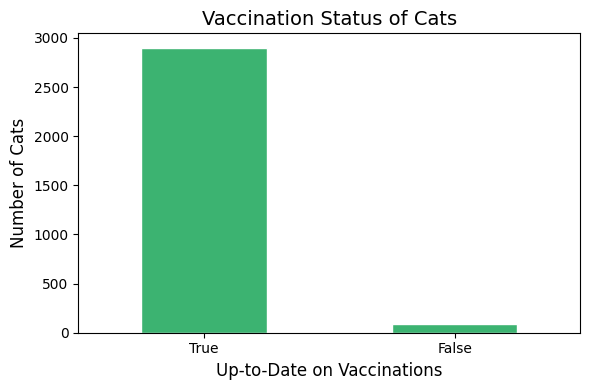

Cats with vaccination status listed: 2995 out of 4528


In [13]:
plt.figure(figsize=(6, 4))
df['isCurrentVaccinations'].value_counts().plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Vaccination Status of Cats', fontsize=14)
plt.xlabel('Up-to-Date on Vaccinations', fontsize=12)
plt.ylabel('Number of Cats', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Cats with vaccination status listed: {df['isCurrentVaccinations'].notna().sum()} out of {len(df)}")

---

## Section 4 — Bivariate Analysis
### How do these variables relate to length of stay?

Now we compare each independent variable against our dependent variable: **`length_of_stay`**, the number of days a cat spent in the system before being adopted. A shorter stay means a faster adoption.

### 4a. Picture Count vs. Length of Stay
Does having more photos in a listing lead to faster adoption? This chart shows the average length of stay for cats grouped by how many pictures their listing had.

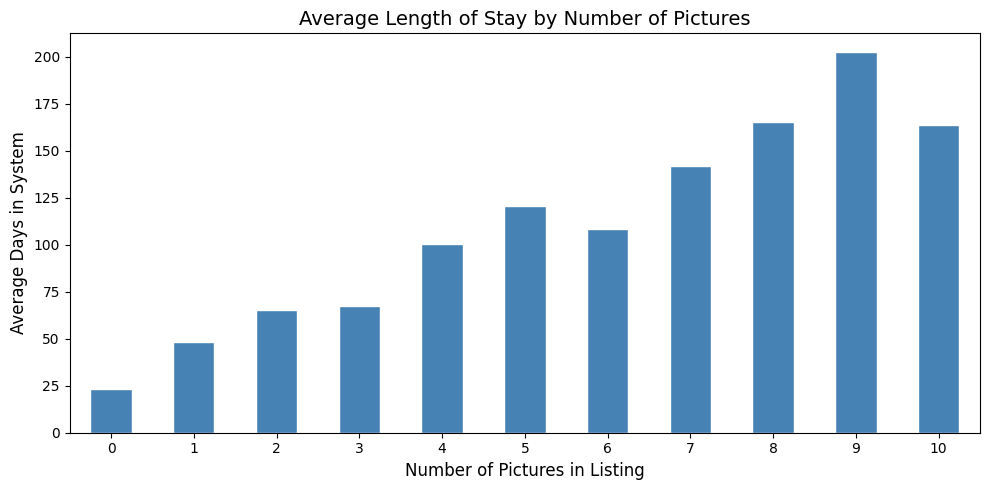

pictureCount
0      23.1
1      48.4
2      65.5
3      67.4
4     100.6
5     120.8
6     108.5
7     142.1
8     165.2
9     202.4
10    163.4
Name: length_of_stay, dtype: float64


In [14]:
avg_los_by_pics = df.groupby('pictureCount')['length_of_stay'].mean().head(11)

plt.figure(figsize=(10, 5))
avg_los_by_pics.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Length of Stay by Number of Pictures', fontsize=14)
plt.xlabel('Number of Pictures in Listing', fontsize=12)
plt.ylabel('Average Days in System', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(avg_los_by_pics.round(1))

### 4b. Vaccination Status vs. Length of Stay
Do cats that are up-to-date on vaccinations get adopted faster? This can help us understand whether health documentation plays a role in adoption speed.

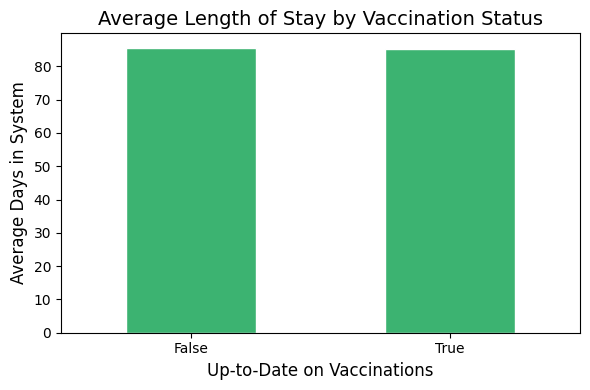

isCurrentVaccinations
False    85.6
True     85.1
Name: length_of_stay, dtype: float64


In [15]:
vacc_df = df.dropna(subset=['isCurrentVaccinations'])

plt.figure(figsize=(6, 4))
vacc_df.groupby('isCurrentVaccinations')['length_of_stay'].mean().plot(
    kind='bar', color='mediumseagreen', edgecolor='white'
)
plt.title('Average Length of Stay by Vaccination Status', fontsize=14)
plt.xlabel('Up-to-Date on Vaccinations', fontsize=12)
plt.ylabel('Average Days in System', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(vacc_df.groupby('isCurrentVaccinations')['length_of_stay'].mean().round(1))

### 4c. Kid-Friendly vs. Length of Stay
Families with children are a large segment of potential adopters. Are cats labeled as kid-friendly adopted more quickly than those that are not?

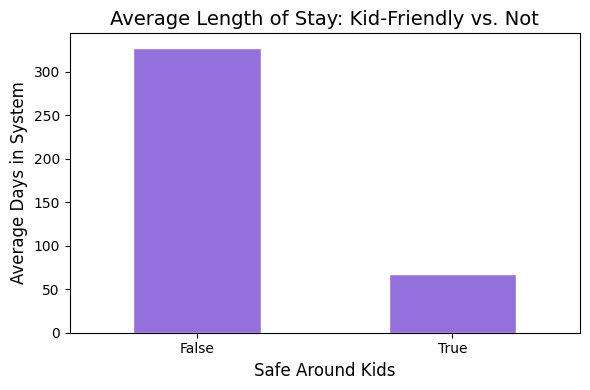

isKidsOk
False    327.8
True      67.4
Name: length_of_stay, dtype: float64


In [16]:
kids_df = df.dropna(subset=['isKidsOk'])

plt.figure(figsize=(6, 4))
kids_df.groupby('isKidsOk')['length_of_stay'].mean().plot(
    kind='bar', color='mediumpurple', edgecolor='white'
)
plt.title('Average Length of Stay: Kid-Friendly vs. Not', fontsize=14)
plt.xlabel('Safe Around Kids', fontsize=12)
plt.ylabel('Average Days in System', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(kids_df.groupby('isKidsOk')['length_of_stay'].mean().round(1))

### 4d. Declawed Status vs. Length of Stay
Some adopters may prefer a declawed cat for practical reasons. Does being declawed affect how long a cat waits to be adopted?

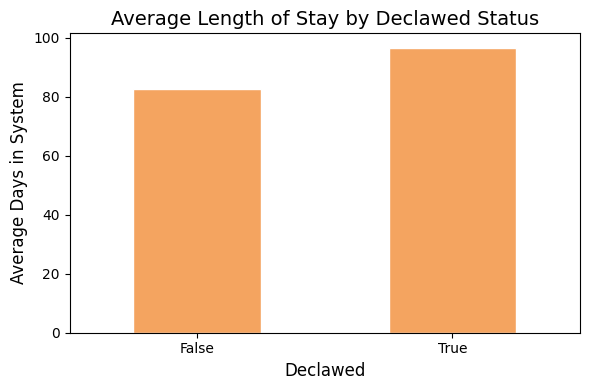

isDeclawed
False    82.8
True     96.7
Name: length_of_stay, dtype: float64


In [17]:
declaw_df = df.dropna(subset=['isDeclawed'])

plt.figure(figsize=(6, 4))
declaw_df.groupby('isDeclawed')['length_of_stay'].mean().plot(
    kind='bar', color='sandybrown', edgecolor='white'
)
plt.title('Average Length of Stay by Declawed Status', fontsize=14)
plt.xlabel('Declawed', fontsize=12)
plt.ylabel('Average Days in System', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(declaw_df.groupby('isDeclawed')['length_of_stay'].mean().round(1))

### 4e. Energy Level vs. Length of Stay
Does a cat's energy level affect how long it takes to find a home? Note: this column has significant missing data (~70%), so conclusions should be interpreted cautiously.

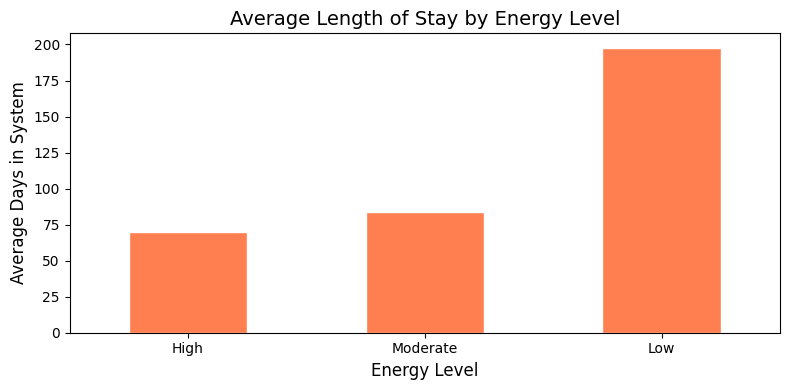

energyLevel
High         70.1
Low         197.8
Moderate     83.6
Name: length_of_stay, dtype: float64


In [18]:
energy_df = df.dropna(subset=['energyLevel'])

plt.figure(figsize=(8, 4))
energy_df.groupby('energyLevel')['length_of_stay'].mean().sort_values().plot(
    kind='bar', color='coral', edgecolor='white'
)
plt.title('Average Length of Stay by Energy Level', fontsize=14)
plt.xlabel('Energy Level', fontsize=12)
plt.ylabel('Average Days in System', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(energy_df.groupby('energyLevel')['length_of_stay'].mean().round(1))

---

## Section 5 — Key Observations & Summary

Below are the main takeaways from this exploratory analysis. These are observations based on patterns in the data — not definitive causal conclusions.

---

### 1. Picture Count Does Not Straightforwardly Predict Adoption Speed
Contrary to what we might expect, cats with **more photos** did not consistently get adopted faster. In fact, cats with **9 pictures** had the longest average stay in the system at around 202 days, while cats with **0 pictures** averaged just 23 days — one of the shorter stays in the dataset.

This likely reflects a **selection bias**: cats that accumulate many photos may be harder-to-adopt animals that have been in the system longer, giving shelter staff more time and reason to photograph them repeatedly. In other words, more photos may be a *result* of a longer stay rather than a *cause* of it. 

Takeaway: Photo count alone is not a reliable predictor of adoption speed. The relationship is likely driven by underlying factors like age, health status, or behavior rather than the listing quality itself.

---

### 2. Vaccination Status Had Almost No Effect on Adoption Speed
Among cats with vaccination status listed, those that were **up-to-date on vaccinations** and those that were **not** showed nearly identical average lengths of stay — 85.1 days versus 85.6 days respectively. This suggests that vaccination status is not a meaningful factor in how quickly a cat gets adopted.

This could mean that most adopters do not prioritize vaccination status when choosing a cat, or that shelters vaccinate cats regardless of how adoptable they appear, making it a poor signal of overall cat desirability.

**Caveat:** Vaccination status was missing for about 33% of cats, so this pattern applies to a subset of the dataset.

---

### 3. Kid-Friendly Cats Were Adopted Significantly Faster
Cats labeled as safe around children had an average length of stay of just **67.4 days**, compared to **327.8 days** for cats that were not kid-friendly. This is one of the strongest differences observed in this entire analysis — cats that are not kid-friendly take nearly **5 times longer** to be adopted.

This makes intuitive sense: families with children represent a large portion of potential adopters, and a cat that cannot be placed in a home with kids immediately eliminates a significant portion of the adopter pool. Cats that are not kid-friendly may also have behavioral challenges that make them harder to place in general.

**Caveat:** This field was missing for nearly 50% of cats, so while the pattern is striking, it applies to a subset of the dataset and should be interpreted with some caution.

---

### 4. Declawed Cats Took Slightly Longer to Be Adopted
Cats that were declawed had an average length of stay of **96.7 days**, compared to **82.8 days** for cats that were not declawed. While the difference is modest, it runs counter to the assumption that declawed cats might be more desirable to adopters.

This could reflect the fact that declawing is increasingly viewed negatively by animal welfare advocates and potential adopters, or it may simply be that declawed cats tend to be older animals that were previously owned — a factor that independently slows adoption regardless of claw status.

**Caveat:** Like other behavioral fields in this dataset, declawed status was missing for a significant portion of cats, which limits how broadly we can apply this finding.

---

### 5. High Energy Cats Were Adopted the Fastest — Low Energy the Slowest
Among cats with an energy level listed, **high energy cats** had the shortest average length of stay at just **70.1 days**, while **low energy cats** waited the longest at **197.8 days**. Moderate energy cats fell in between at **83.6 days**.

This is a surprising finding — one might expect calmer, low energy cats to be more universally appealing. However, it may reflect that high energy cats tend to be younger animals, and as we saw in Victor's analysis, younger cats (babies and young adults) are adopted much faster than seniors. Low energy cats may skew older, which would independently increase their time in the system.

**Caveat:** Only about 30% of cats had an energy level listed, so this pattern applies to a small subset of the dataset and may not be representative of all cats in the system.

---

### Overall Conclusion
The most striking finding in this analysis was the relationship between **kid-friendliness and adoption speed** — cats that were not safe around children took nearly five times longer to be adopted than those that were, suggesting that compatibility with family households is one of the strongest drivers of adoption outcomes in this dataset.

**Energy level** also showed a notable pattern, with high energy cats being adopted fastest and low energy cats waiting the longest — though this may be driven by age rather than energy itself, since younger cats tend to have higher energy and are generally adopted more quickly.

**Declawed status** showed a small but unexpected disadvantage for declawed cats, while **vaccination status** showed virtually no difference in adoption speed at all — suggesting that health documentation alone is not a meaningful signal to most adopters.

**Photo count** did not behave as expected — cats with more photos actually tended to stay longer, likely because difficult-to-adopt cats accumulate more photos over time rather than photos driving faster adoption.

It is important to note that **missing data is a significant limitation** across nearly all behavioral fields in this dataset. Kid-friendliness, declawed status, vaccination status, and energy level were each missing for 30–70% of cats, meaning our findings apply to subsets of the data rather than the full population. Encouraging shelters to consistently fill in these fields would greatly improve the reliability of future analyses.